## 1) GBM
* 부스팅 알고리즘
  * 여러 개의 약한 학습기(weak learner)을 순차적으로 학습&예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해나가며 학습하는 방식
  * 대표적 구현 방식
    * 에이다 부스트(AdaBoost, Adaptive Boosting)
    * 그래디언트 부스트(GBM, Gradient Boost Machine)
* 에이다 부스트
  * 오류 데이터에 가중치를 부여하며 부스팅을 수행하는 알고리즘
  * 개별의 약한 학습기가 각각의 가중치를 부여해 결합함
* GBM
  * 에이다 부스트와 유사하나, 가중치 업데이트를 경사 하강법(gradient descent)를 이용함
  * 경사 하강법
    * 오류 값 = 실제값 - 예측값
    * 분류 실제 결과값 = y, 피처=x1, x2, xn..., 피처에 기반한 예측 함수=F(x)
    * 오류식 h(x) = y - F(x)를 최소화하는 방향성을 가지고 반복적으로 가중치 값을 업데이트함
  * 반복 수행을 통해 오류를 최소화할 수 있도록 가중치의 업데이트값을 도출하는 기법
  * 분류와 회귀 모두 가능
  * 사이킷런에서 분류로 GradientBoostingClassifier 클래스 사용
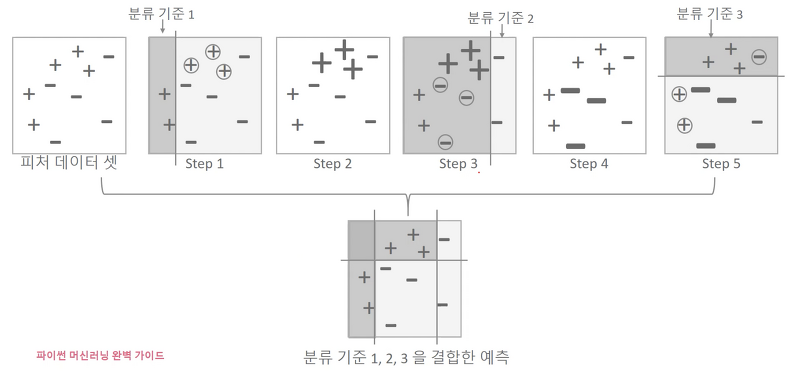

## 2) GBM 하이퍼 파라미터 및 튜닝
* 트리 기반 자체의 파라미터도 있음(설명 생략)
* loss : 경사하강법에서 사용할 비용 함수. 디폴트='deviance'
* learning_rate : 학습을 진행할 때마다 적용하는 학습율로, 약한 학습기가 순차적으로 오류값을 보정해나가는데 적용하는 계수. 0~1사이. 디폴트=0.1. 작은 값에서는 에측 성능 높아지나 시간 오래걸ㅣ고 약한 학습기의 반복이 완료되어도 최소 오류값 찾지 못할 수 있음. n_estimator와 조합해 사용
* n_estimator : 약한 학습기의 개수. 많을 수록 예측 선은이 일정 수준까지 좋아지나 오래걸림
* subsample : 약한 학습기가 학습에 사용하는 데이터 샘플링의 비율. 기본값=1(전체 학습 데이터 기반으로 함)

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

### 데이터셋(4.4 참조)
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x: str(x[0]) + '_' + str(x[1]) if x[1]>0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

def get_human_dataset():
    # 각 데이터파일은 공백으로 분리됨 -> sep을 공백으로 할당
    feature_name_df = pd.read_csv(r'../human_activity/features.txt', sep='\+', header=None, names=['column_index', 'column_name'])
    # 중복된 피처명 수정하는 함수 이용
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    # 학습 피처 데이터셋과 테스트 피처 데이터셋을 dataFrame으로 로딩
    x_train = pd.read_csv(r'../human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    x_test = pd.read_csv(r'../human_activity/test/X_test.txt', sep='\s+', names=feature_name)
    #학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩. 칼럼명은 action 으로 부여
    y_train = pd.read_csv(r'../human_activity/train/y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv(r'../human_activity/test/y_test.txt', sep='\s+', header=None, names=['action'])
    #로드된 학습/테스트용 DataFrame을 모두 반환
    return x_train, x_test, y_train, y_test

### 학습 및 정확도 측정
x_train, x_test, y_train, y_test = get_human_dataset()
gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(x_train, y_train)
gb_pred = gb_clf.predict(x_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
print('GBM 정확도 : {0:.4f}'.format(gb_accuracy))

KeyboardInterrupt: 

In [ ]:
### 최적 하이퍼 파라미터

params = {'n_estimators':[100, 500], 'learning_rate':[0.05, 0.1]}
grid_cv = GridSearchCV(gb_clf, param_grid=params, cv=2, verbose=1)
grid_cv.fit(x_train, y_train)

print('최적 하이퍼 파라미너 : \n', grid_cv.best_params_)
print('최고 예측 정확도 : {0:.4f}'.format(grid_cv.best_score_))

In [ ]:
gb_pred = grid_cv.best_estimator_.predict(x_test)
gb_accuarcy = accuracy_score(y_test, gb_pred)
print('GBM 정확도 : {0:.4f}'.format(gb_accuarcy))